In [20]:
import sys
sys.path.append('..')

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statistics import mean
from datetime import date
import file
from yfetch import get_stock_history

In [21]:
# Define the ticker symbol
symbol = 'SPMO'

# Get the historical prices for this ticker
history = get_stock_history(symbol, period='5y', interval='1wk')

In [22]:
ch29w = history.Close.pct_change(periods=29)
print('mean 29w change', ch29w.mean())
print('median 29w change', ch29w.median())

mean 29w change 0.10890706114754328
median 29w change 0.11216836984217537


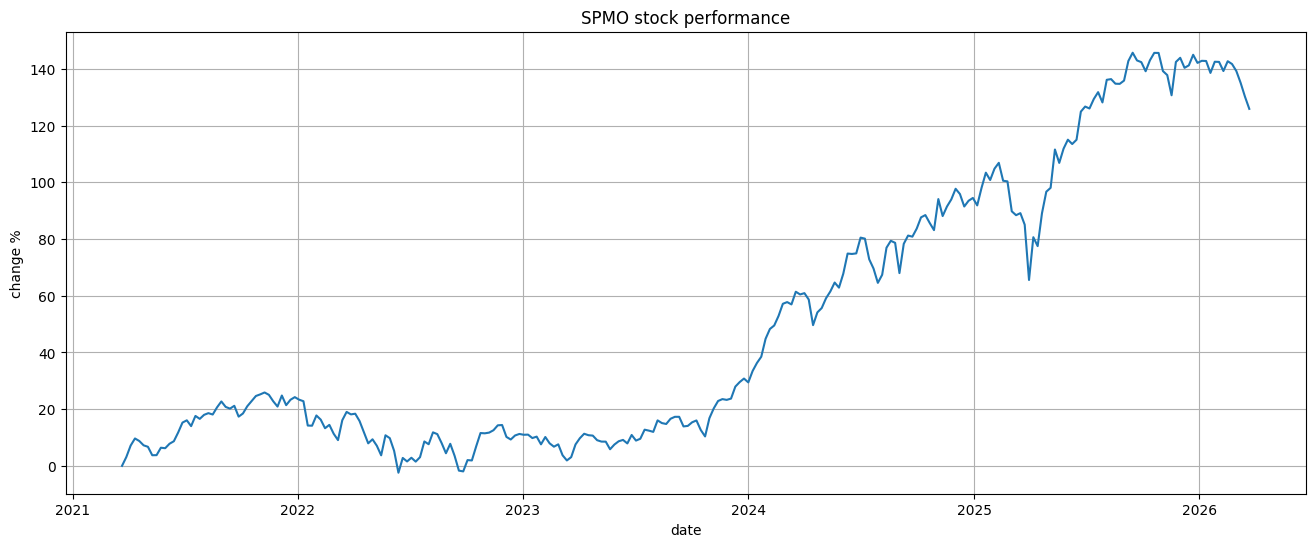

In [23]:
plt.figure(figsize=(16,6))
plt.plot((history.Close / history.Close.iloc[0]) * 100 - 100)
plt.title(symbol + ' stock performance')
plt.xlabel('date')
plt.ylabel('change %')
plt.grid()
plt.show()

In [24]:
stock_changes = history['Close'].pct_change(periods=1).dropna()
median_change = stock_changes.median()
print(f'Median weekly change for {symbol}: {median_change:.2%}')

Median weekly change for SPMO: 0.30%


In [25]:

gap = (0.5 / 110) * 100 # %

option_prices = {
    29: [112/8.6],
}

print('option leverages:')
for w in sorted(option_prices.keys()):
    print(f'\t{w:2}w', *[f'{x:4.1f}' for x in option_prices[w]])

option_leverage = {w:mean(option_prices[w]) for w in option_prices}

# normalize values so longer expirations have lower leverage
option_leverage = {k: v for k, v in zip(sorted(option_leverage.keys()), sorted(option_leverage.values(), reverse=True))}

print('mean option leverage, break even:')
for w in sorted(option_leverage.keys()):
    print(f'\t{w:2}w {option_leverage[w]:5.1f} {gap + 100/option_leverage[w]:4.1f}%')
print(f'option gap: {gap:.2f}%')

file.save_option_leverage(symbol, option_leverage)

option leverages:
	29w 13.0
mean option leverage, break even:
	29w  13.0  8.1%
option gap: 0.45%


In [26]:
max_weeks = 52
stock_change = [None]
for weeks in range(1, max_weeks+1):
    stock_changes = history['Close'].pct_change(periods=weeks) * 100
    stock_change.append(stock_changes.mean()) # ** (1/weeks))
    
    if weeks in option_leverage:
        lvr = option_leverage[weeks]
        option_profits = ((stock_changes[weeks:] - gap) * lvr - 100).clip(lower=-100)
        mean_profit = option_profits.mean() / weeks
        median_profit = option_profits.median() / weeks
        positive_percent = (option_profits > 0).mean() * 100
        history[f'Option {weeks}w'] = option_profits

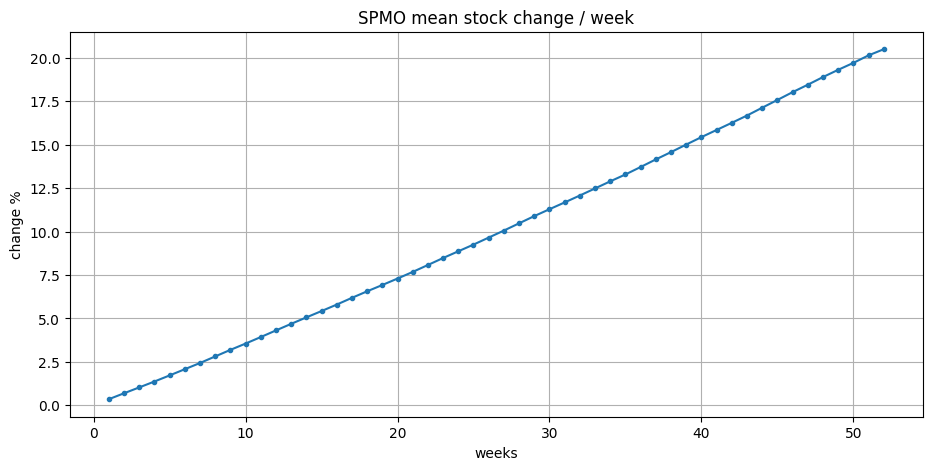

In [27]:
plt.figure(figsize=(11,5))
plt.plot(stock_change, marker='.')
plt.title(symbol + ' mean stock change / week')
plt.xlabel('weeks')
plt.ylabel('change %')
plt.grid()
plt.show()


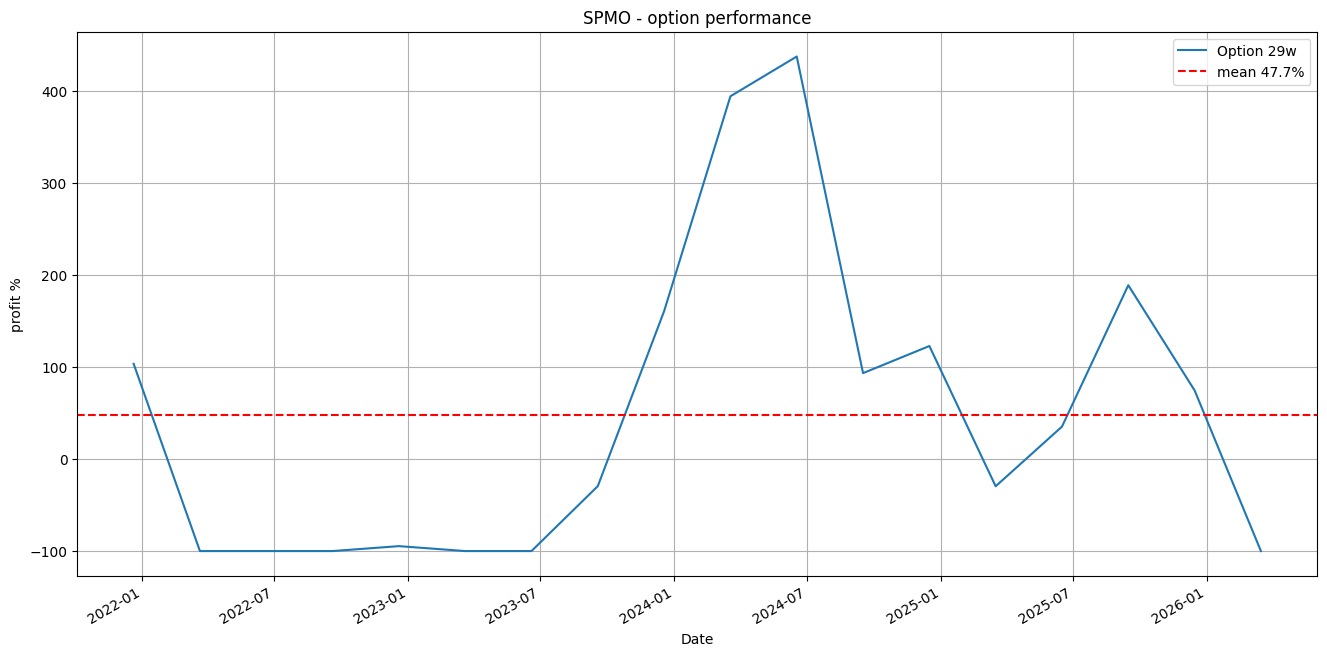

In [31]:
plt.figure(figsize=(16,8))

op = history[f'Option 29w'].iloc[::13]
op.plot()
mean_profit = op.mean()
plt.axhline(y=mean_profit, color='r', linestyle='--', label=f'mean {mean_profit:.1f}%')
plt.legend()
plt.title(f'{symbol} - option performance')
plt.ylabel('profit %')
plt.grid()
plt.show()


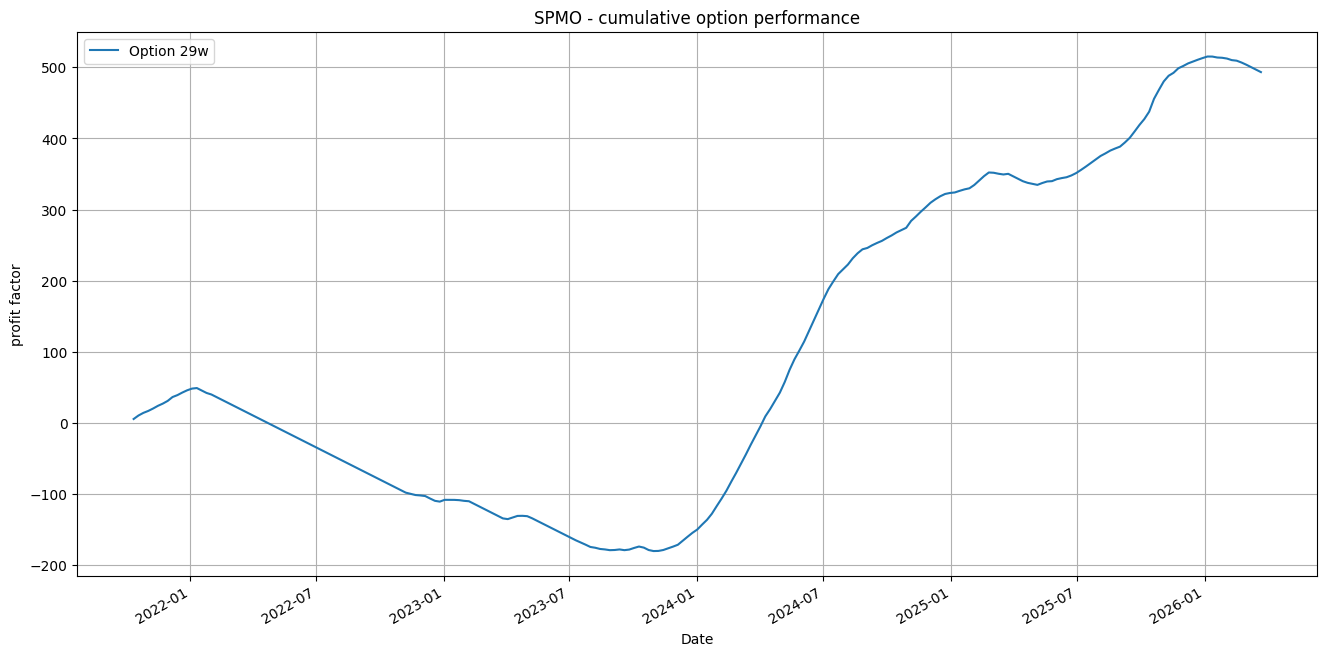

In [29]:
plt.figure(figsize=(16,8))

for w in [29]:
    (history[f'Option {w}w'].cumsum()/w).plot()

plt.legend()
plt.title(f'{symbol} - cumulative option performance')
plt.ylabel('profit factor')
plt.grid()
plt.show()
